# Guéant–Lehalle–Fernandez-Tapia Market Making Model and Grid Trading
# 朱安-勒哈勒-费尔南德斯-塔皮亚做市商模型与网格交易

## Overview
## 概述

Grid trading is straightforward and easy to comprehend, and it excels in high-frequency environments. However, given the intricacies of high-frequency trading, which necessitate comprehensive tick-by-tick simulation with latencies and order fill simulation, optimizing the ideal spread, order interval, and skew can be a challenging task. Furthermore, these values fluctuate over time, especially in response to market conditions, making a fixed setup less than optimal.

网格交易操作简单易懂，且在高频交易环境中表现卓越。然而，鉴于高频交易的复杂性（需要进行详细的逐笔模拟，包括延迟和订单成交模拟），优化理想的价差、订单间隔和倾斜度可能是一项颇具挑战性的任务。此外，这些数值会随时间变化，尤其是在受到市场条件影响时，因此固定设置并非最佳选择。

To improve grid trading's adaptability, one solution is to combine it with a well-developed market-making model. Let's delve into how this can be achieved.

为了提高网格交易的适应性，一种解决方案是将其与成熟的做市商模式相结合。接下来让我们探讨一下如何实现这一目标。

## Guéant–Lehalle–Fernandez-Tapia Market Making Model
## 朱安-勒哈勒-费尔南德斯-塔皮亚做市商模型

This model represents an advanced evolution of the well-known Avellaneda-Stoikov model and provides a closed-form approximation of asymptotic behavior for terminal time T. Simply, this model does not specify a terminal time, which makes it suitable for typical stocks, spot assets, or crypto perpetual contracts. By employing this model, it is anticipated that the half spread and skew will be accurately adjusted according to market conditions.

该模型是对著名的阿韦拉内达-斯托伊科夫模型的高级改进，并能为终端时间 T 的渐近行为提供一种封闭形式的近似值。简而言之，此模型不设定终端时间，因此适用于典型的股票、现货资产或加密永续合约。通过使用此模型，预计半价差和偏度将根据市场状况得到准确调整。

In this analysis, we will focus on equations (4.6) and (4.7) in [Optimal market making](https://arxiv.org/abs/1605.01862) and explore how they can be applied to real-world scenarios.

在本次分析中，我们将重点研究 [Optimal market making](https://arxiv.org/abs/1605.01862) 中的方程（4.6）和（4.7），并探讨如何将它们应用于实际场景中。

The optimal bid quote depth, $\delta^{b*}_{approx}$, and ask quote depth, $\delta^{a*}_{approx}$, are derived from the fair price as follows:

最优的报价深度（即买方报价深度）$\delta^{b*}_{approx}$ 和 最高的报价深度（即卖方报价深度）$\delta^{a*}_{approx}$ 是根据公平价格计算得出的：


$$
\begin{aligned}
\delta^{b*}_{approx}(q) &= \frac{1}{\xi \Delta}\log\left(1 + \frac{\xi \Delta}{k}\right) + \frac{2q + \Delta}{2}\sqrt{\frac{\gamma \sigma^2}{2A\Delta k}\left(1 + \frac{\xi \Delta}{k}\right)^{\frac{k}{\xi \Delta} + 1}} & (4.6) \\
\delta^{a*}_{approx}(q) &= \frac{1}{\xi \Delta}\log\left(1 + \frac{\xi \Delta}{k}\right) - \frac{2q - \Delta}{2}\sqrt{\frac{\gamma \sigma^2}{2A\Delta k}\left(1 + \frac{\xi \Delta}{k}\right)^{\frac{k}{\xi \Delta} + 1}} & (4.7)
\end{aligned}
$$

Let's introduce $c_1$ and $c_2$ and define them by extracting the volatility 𝜎 from the square root:

让我们引入变量 $c_1$ 和 $c_2$ ，并通过从平方根中提取波动率 $\sigma$ 来对其进行定义：

\begin{align}
c_1 = {1 \over {\xi \Delta}}log(1 + {\xi \Delta \over k}) \\
c_2 = \sqrt{{\gamma \over {2A\Delta k}}(1 + {\xi \Delta \over k})^{{k \over {\xi \Delta}} + 1}}
\end{align}

Now we can rewrite equations (4.6) and (4.7) as follows:

现在我们可以将方程（4.6）和（4.7）重新表述为如下形式：

\begin{align}
\delta^{b*}_{approx}(q) = c_1 + {\Delta \over 2} \sigma c_2 + q \sigma c_2 \\
\delta^{a*}_{approx}(q) = c_1 + {\Delta \over 2} \sigma c_2 - q \sigma c_2
\end{align}

As you can see, this consists of the half spread and skew. $q$ represents a market maker's inventory(position).

如您所见，这包括半价差和斜率。$q$ 表示做市商的库存（持仓）。

\begin{align}
\text{half spread} = C_1 + {\Delta \over 2} \sigma C_2 \\
\text{skew} = \sigma C_2 \\
\delta^{b*}_{approx}(q) = \text{half spread} + \text{skew} \times q \\
\delta^{a*}_{approx}(q) = \text{half spread} - \text{skew} \times q
\end{align}

Thus,

因此，

\begin{align}
\text{bid price} = \text{fair price} - (\text{half spread} + \text{skew} \times q) \\
\text{ask price} = \text{fair price} + (\text{half spread} - \text{skew} \times q)
\end{align}

You can find similarities in what the following two articles describe.  
[Stochastic Control Theory and High Frequency Trading](https://ieor.columbia.edu/files/seasdepts/industrial-engineering-operations-research/pdf-files/Borden_D_FESeminar_Sp10.pdf)  
[How to Market Make Bitcoin Derivatives Lesson 2](https://blog.bitmex.com/how-to-market-make-bitcoin-derivatives-lesson-2/)  

您可以在以下两篇文章所描述的内容中发现相似之处。

[随机控制理论与高频交易](https://ieor.columbia.edu/files/seasdepts/industrial-engineering-operations-research/pdf-files/Borden_D_FESeminar_Sp10.pdf)

[如何发行比特币衍生品 第 2 课](https://blog.bitmex.com/how-to-market-make-bitcoin-derivatives-lesson-2/)

## Calculating Trading Intensity
## 计算交易强度
To determine the optimal quotes, we need to compute $c_1$ and $c_2$. In order to do that, we need to calibrate $A$ and $k$ of trading intensity, as well as calculate the market volatility $\sigma$.

为了确定最优报价，我们需要计算 $c_1$ 和 $c_2$。要实现这一点，我们需要对交易强度的 $A$ 和 $k$ 进行校准，并计算市场波动率 $\sigma$。

Trading intensity is defined as:

交易强度的定义为：

$$ \lambda = A \exp (-k \delta) $$

We will calibrate these values using market data according to [the this article](https://quant.stackexchange.com/questions/36073/how-does-one-calibrate-lambda-in-a-avellaneda-stoikov-market-making-problem). In order to do that, we need to record market order's arrivals.

我们将根据[本文](https://quant.stackexchange.com/questions/36073/how-does-one-calibrate-lambda-in-a-avellaneda-stoikov-market-making-problem)中的内容，利用市场数据来校准这些数值。为此，我们需要记录市场订单的到达情况。

Our market maker will react every 100ms, which means they will post or cancel orders at this interval. So, our quotes' trading intensity will be measured in the same time-step. Ideally, we should also account for our orders' queue position; however, to simplify the problem, we will not consider the order queue position in this analysis.

我们的做市商每 100 毫秒就会做出一次反应，这意味着他们会在这个时间间隔内挂单或撤单。因此，我们的报价的交易强度将按照同样的时间步长来衡量。理想情况下，我们还应该考虑我们订单的排队位置；然而，为了简化问题，本次分析中我们将不考虑订单的排队位置。

In [2]:
from numba import njit
from hftbacktest import BUY_EVENT

import numpy as np

@njit
def measure_trading_intensity_and_volatility(hbt):
    tick_size = hbt.depth(0).tick_size
    arrival_depth = np.full(10_000_000, np.nan, np.float64)
    mid_price_chg = np.full(10_000_000, np.nan, np.float64)

    t = 0
    prev_mid_price_tick = np.nan
    mid_price_tick = np.nan
    
    # Checks every 100 milliseconds.
    while hbt.elapse(100_000_000) == 0:
        #--------------------------------------------------------
        # Records market order's arrival depth from the mid-price.
        if not np.isnan(mid_price_tick):
            depth = -np.inf
            for last_trade in hbt.last_trades(0):
                trade_price_tick = last_trade.px / tick_size
                
                if last_trade.ev & BUY_EVENT == BUY_EVENT:
                    depth = np.nanmax([trade_price_tick - mid_price_tick, depth])
                else:
                    depth = np.nanmax([mid_price_tick - trade_price_tick, depth])
            arrival_depth[t] = depth
        
        hbt.clear_last_trades(0)

        depth = hbt.depth(0)

        best_bid_tick = depth.best_bid_tick
        best_ask_tick = depth.best_ask_tick
        
        prev_mid_price_tick = mid_price_tick
        mid_price_tick = (best_bid_tick + best_ask_tick) / 2.0
        
        # Records the mid-price change for volatility calculation.
        mid_price_chg[t] = mid_price_tick - prev_mid_price_tick
        
        t += 1
        if t >= len(arrival_depth) or t >= len(mid_price_chg):
            raise Exception
    return arrival_depth[:t], mid_price_chg[:t]

Since we're not considering the order's queue position when measuring trading intensity, only market trades that cross our quote will be counted as executed.

由于我们在衡量交易强度时并未考虑订单的排队位置，因此只有那些超出我们报价范围的市场交易才会被算作已完成交易。

<div class="alert alert-info">

**Note:** The trading intensity in `out` of `measure_trading_intensity` is incorrectly in half-tick units instead of tick units. Although this fix requires adjusting parameters in all related examples, the example is left unchanged to preserve existing results.

**注意：** 在 `measure_trading_intensity` 函数的 `out` 中，交易强度的计量单位（即“半 Tick 单位”而非“Tick 单位”）存在错误。尽管此修正需要对所有相关示例中的参数进行调整，但为了保持现有结果不变，示例未作修改。
</div>

In [3]:
@njit
def measure_trading_intensity(order_arrival_depth, out):
    max_tick = 0
    for depth in order_arrival_depth:
        if not np.isfinite(depth):
            continue
        
        # Sets the tick index to 0 for the nearest possible best price 
        # as the order arrival depth in ticks is measured from the mid-price
        tick = round(depth / .5) - 1
        
        # In a fast-moving market, buy trades can occur below the mid-price (and vice versa for sell trades) 
        # since the mid-price is measured in a previous time-step; 
        # however, to simplify the problem, we will exclude those cases.
        if tick < 0 or tick >= len(out):
            continue
        
        # All of our possible quotes within the order arrival depth, 
        # excluding those at the same price, are considered executed.
        out[:tick] += 1
        
        max_tick = max(max_tick, tick)
    return out[:max_tick]

Run HftBacktest to replay the market and record order arrival depth and price changes.

运行“HftBacktest”程序来重现市场情况，并记录订单到达的深度以及价格的变化情况。

In [4]:
from hftbacktest import BacktestAsset, ROIVectorMarketDepthBacktest

asset = (
    BacktestAsset()
        .data([
            'usdm/ethusdc_20260301.npz'
        ])
        .initial_snapshot('usdm/ethusdc_20260228_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency([
            'usdm/feed_latency_ethusdc_20260301.npz'
        ])
        .power_prob_queue_model(2.0) 
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.01)
        .lot_size(0.001)
        .roi_lb(0.0)    
        .roi_ub(3000.0)
        .last_trades_capacity(10000)
)

hbt = ROIVectorMarketDepthBacktest([asset])

arrival_depth, mid_price_chg = measure_trading_intensity_and_volatility(hbt)

_ = hbt.close()

Measure trading intensity from the recorded order arrival depth and plot it.

根据记录的订单到达深度来衡量交易的活跃程度，并将其绘制成图表。

In [5]:
tmp = np.zeros(500, np.float64) 

# Measures trading intensity (lambda) for the first 10-minute window.
lambda_ = measure_trading_intensity(arrival_depth[:6_000], tmp)

# Since it is measured for a 10-minute window, divide by 600 to convert it to per second.
lambda_ /= 600

# Creates ticks from the mid-price.
ticks = np.arange(len(lambda_)) + .5

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/cq/t7280jl920z2pzmhdmv0mzw80000gn/T/ipykernel_44904/1671814744.py:4: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$ \delta $ (ticks from the mid-price)')


Text(0, 0.5, 'Count (per second)')

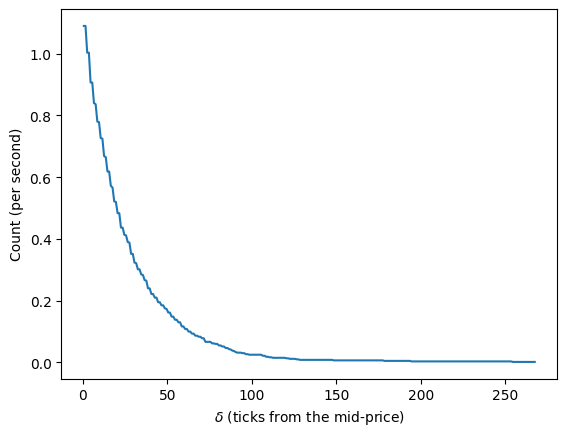

In [6]:
from matplotlib import pyplot as plt

plt.plot(ticks, lambda_)
plt.xlabel('$ \delta $ (ticks from the mid-price)')
plt.ylabel('Count (per second)')

Calibrate $A$ and $k$ using linear regression, since by taking the logarithm of both sides of lambda, it becomes $log \lambda = -k \delta + logA$.

使用线性回归来校准变量 $A$ 和 $k$，因为将 $\lambda$ 的两边取对数后，会得到 $log \lambda = -k \delta + logA$ 。

In [7]:
@njit
def linear_regression(x, y):
    sx = np.sum(x)
    sy = np.sum(y)
    sx2 = np.sum(x ** 2)
    sxy = np.sum(x * y)
    w = len(x)
    slope = (w * sxy - sx * sy) / (w * sx2 - sx**2)
    intercept = (sy - slope * sx) / w
    return slope, intercept

In [8]:
y = np.log(lambda_)
k_, logA = linear_regression(ticks, y)
A = np.exp(logA)
k = -k_

print('A={}, k={}'.format(A, k))

A=0.4269281056408313, k=0.023111842315581537


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/var/folders/cq/t7280jl920z2pzmhdmv0mzw80000gn/T/ipykernel_44904/724309136.py:3: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$ \delta $ (ticks from the mid-price)')


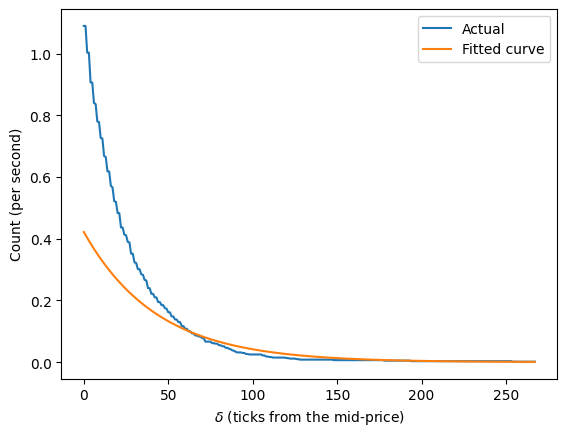

In [9]:
plt.plot(lambda_)
plt.plot(A * np.exp(-k * ticks))
plt.xlabel('$ \delta $ (ticks from the mid-price)')
plt.ylabel('Count (per second)')
plt.legend(['Actual', 'Fitted curve'])

As you can see, the fitted lambda function is not accurate across the entire range. More specifically, it overestimates the trading intensity for the shallow range near the mid-price and underestimates it for the deep range away from the mid-price.

如您所见，所拟合的 lambda 函数在整个范围内并不准确。更具体地说，它在接近中间价的浅区域高估了交易强度，在远离中间价的深区域则低估了交易强度。

Since our quotes are likely to be placed in the range close to the mid-price, at least under typical market conditions (excluding high volatility conditions), we will refit the function specifically for the nearest range.

由于我们的报价很可能处于接近中间价的范围内，至少在通常的市场状况下（不包括高波动性情况），我们将专门针对最接近的这个价格区间重新调整该功能。

In [10]:
# Refits for the range un to 70 ticks.
x_shallow = ticks[:70]
lambda_shallow = lambda_[:70]

y = np.log(lambda_shallow)
k_, logA = linear_regression(x_shallow, y)
A = np.exp(logA)
k = -k_

print('A={}, k={}'.format(A, k))

A=1.0802363656065261, k=0.03770624833386272


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/var/folders/cq/t7280jl920z2pzmhdmv0mzw80000gn/T/ipykernel_44904/303205158.py:3: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$ \delta $ (ticks from the mid-price)')


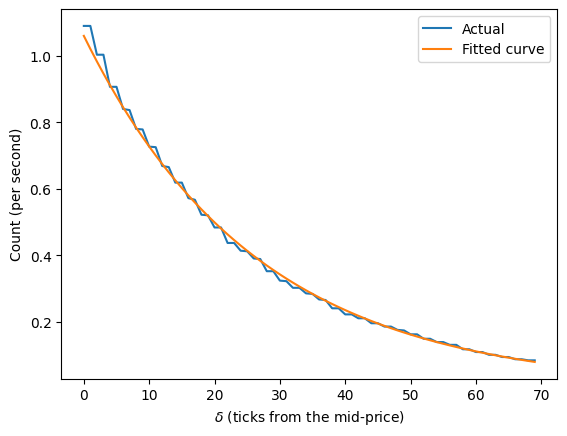

In [11]:
plt.plot(lambda_shallow)
plt.plot(A * np.exp(-k * x_shallow))
plt.xlabel('$ \delta $ (ticks from the mid-price)')
plt.ylabel('Count (per second)')
plt.legend(['Actual', 'Fitted curve'])

Now, we have a more accurate trading intensity function. Let's see where our quote will be placed.

现在，我们有了一个更为精确的交易活跃度函数。接下来，让我们看看我们的报价会放在哪里。

But before we do that, let's calculate the volatility first.

但在我们进行下一步操作之前，先来计算一下波动率吧。

In [12]:
# Since we need volatility in ticks per square root of a second and our measurement is every 100ms, 
# multiply by the square root of 10.
volatility = np.nanstd(mid_price_chg) * np.sqrt(10)
print(volatility)

27.567807764919458


Compute $c_1$ and $c_2$ according to the equations.

根据这些方程计算出 $c_1$ 和 $c_2$ 的值。

In [13]:
@njit
def compute_coeff(xi, gamma, delta, A, k):
    inv_k = np.divide(1, k)
    c1 = 1 / (xi * delta) * np.log(1 + xi * delta * inv_k)
    c2 = np.sqrt(np.divide(gamma, 2 * A * delta * k) * ((1 + xi * delta * inv_k) ** (k / (xi * delta) + 1)))
    return c1, c2

In the Guéant–Lehalle–Fernandez-Tapia formula, $\Delta = 1$ and $\xi = \gamma$. the value of $\gamma$ is arbitrarily chosen.

在盖昂-勒哈勒-费尔南德斯-塔皮亚公式中，$\Delta = 1$ 且 $\xi = \gamma$。而 $\gamma$ 的值则是任意选定的。

In [14]:
gamma = 0.05
delta = 1
volatility = 10.69

c1, c2 = compute_coeff(gamma, gamma, delta, A, k)

half_spread_tick = 1 * c1 + 1 / 2 * c2 * volatility
skew = c2 * volatility
print('half_spread_tick={}, skew={}'.format(half_spread_tick, skew))

half_spread_tick=25.663414031459794, skew=17.560135082884333


What does it mean when your quote is positioned 20 ticks away from the mid-price? By analyzing the recorded order arrival depth, you can identify the number of market trades you'll participate in as a market maker, measured in terms of count instead of volume. Additionally, the skew appears to be quite strong, as accumulating just two positions offsets the entire half spread.

当您的报价与中间价相差 20 个点时，这意味着什么？通过分析记录的订单到达深度，您可以确定作为做市商您将参与的市场交易数量（以数量而非成交量来衡量）。此外，这种偏差似乎相当显著，因为仅增加两个仓位就能抵消整个半价差。

In [16]:
from scipy import stats

# inverse of percentile
pct = stats.percentileofscore(arrival_depth[np.isfinite(arrival_depth)], half_spread_tick)
your_pct = 100 - pct
print('{:.2f}%'.format(your_pct))

14.02%


Approximately 1.86% of market trades per given time-step could execute your quote. Be aware that it's not the percentage of the traded quantity.

在每个时间点，大约有 1.86% 的市场交易能够执行您的报价。请注意，这并非是交易量所占的百分比。

## Implement a Market Maker using the Model
## 利用该模型实现市场做市商功能


<div class="alert alert-info">
    
**Note:** This example is for educational purposes only and demonstrates effective strategies for high-frequency market-making schemes. All backtests are based on a 0.005% rebate, the highest market maker rebate available on Binance Futures. See <a href="https://www.binance.com/en/support/announcement/binance-updates-usd%E2%93%A2-margined-futures-liquidity-provider-program-2024-06-03-fefc6aa25e0947e2bf745c1c56bea13e">Binance Upgrades USDⓢ-Margined Futures Liquidity Provider Program</a> for more details.

**注意：** 本示例仅用于教育目的，旨在展示高频市场撮合方案的有效策略。所有回测均基于 0.005% 的返佣比例，这是在币安期货上可获得的最高市场撮合返佣。详情请参阅 <a href="https://www.binance.com/en/support/announcement/binance-upgrades-usd%E2%93%A2-margined-futures-liquidity-provider-program-2024-06-03-fefc6aa25e0947e2bf745c1c56bea13e">币安升级 USDⓢ-保证金期货流动性提供者计划</a> 以获取更多信息。
    
</div>

In this example, we will disregard the forecast term and assume that the fair price is equal to the mid price, as we can expect the intrinsic value to remain stable in the short term.

在本例中，我们将忽略预测期限这一因素，并假设公平价格等于中间价格，因为我们可以预期其内在价值在短期内会保持稳定。

In [17]:
from numba.typed import Dict
from hftbacktest import BUY, SELL, GTX, LIMIT

out_dtype = np.dtype([
    ('half_spread_tick', 'f8'), 
    ('skew', 'f8'), 
    ('volatility', 'f8'), 
    ('A', 'f8'), 
    ('k', 'f8')
])

@njit
def glft_market_maker(hbt, recorder):
    tick_size = hbt.depth(0).tick_size
    arrival_depth = np.full(10_000_000, np.nan, np.float64)
    mid_price_chg = np.full(10_000_000, np.nan, np.float64)
    out = np.zeros(10_000_000, out_dtype)

    t = 0
    prev_mid_price_tick = np.nan
    mid_price_tick = np.nan
    
    tmp = np.zeros(500, np.float64)
    ticks = np.arange(len(tmp)) + 0.5
    
    A = np.nan
    k = np.nan
    volatility = np.nan
    gamma = 0.05
    delta = 1

    order_qty = 1
    max_position = 20
    
    # Checks every 100 milliseconds.
    while hbt.elapse(100_000_000) == 0:
        #--------------------------------------------------------
        # Records market order's arrival depth from the mid-price.
        if not np.isnan(mid_price_tick):
            depth = -np.inf
            for last_trade in hbt.last_trades(0):
                trade_price_tick = last_trade.px / tick_size
                
                if last_trade.ev & BUY_EVENT == BUY_EVENT:
                    depth = np.nanmax([trade_price_tick - mid_price_tick, depth])
                else:
                    depth = np.nanmax([mid_price_tick - trade_price_tick, depth])
            arrival_depth[t] = depth
        
        hbt.clear_last_trades(0)
        hbt.clear_inactive_orders(0)
        
        depth = hbt.depth(0)
        position = hbt.position(0)
        orders = hbt.orders(0)

        best_bid_tick = depth.best_bid_tick
        best_ask_tick = depth.best_ask_tick
        
        prev_mid_price_tick = mid_price_tick
        mid_price_tick = (best_bid_tick + best_ask_tick) / 2.0
        
        # Records the mid-price change for volatility calculation.
        mid_price_chg[t] = mid_price_tick - prev_mid_price_tick
        
        #--------------------------------------------------------
        # Calibrates A, k and calculates the market volatility.
        
        # Updates A, k, and the volatility every 5-sec.
        if t % 50 == 0:
            # Window size is 10-minute.
            if t >= 6_000 - 1:
                # Calibrates A, k
                tmp[:] = 0
                lambda_ = measure_trading_intensity(arrival_depth[t + 1 - 6_000:t + 1], tmp)
                if len(lambda_) > 2:
                    lambda_ = lambda_[:70] / 600
                    x = ticks[:len(lambda_)]
                    y = np.log(lambda_)
                    k_, logA = linear_regression(x, y)
                    A = np.exp(logA)
                    k = -k_
           
                # Updates the volatility.
                volatility = np.nanstd(mid_price_chg[t + 1 - 6_000:t + 1]) * np.sqrt(10)
    
        #--------------------------------------------------------
        # Computes bid price and ask price.
    
        c1, c2 = compute_coeff(gamma, gamma, delta, A, k)
        
        half_spread_tick = c1 + delta / 2 * c2 * volatility
        skew = c2 * volatility

        reservation_price_tick = mid_price_tick - skew * position

        bid_price_tick = np.minimum(np.round(reservation_price_tick - half_spread_tick), best_bid_tick)
        ask_price_tick = np.maximum(np.round(reservation_price_tick + half_spread_tick), best_ask_tick)
        
        bid_price = bid_price_tick * tick_size
        ask_price = ask_price_tick * tick_size
        
        #--------------------------------------------------------
        # Updates quotes.
        
        # Cancel orders if they differ from the updated bid and ask prices.
        order_values = orders.values();
        while order_values.has_next():
            order = order_values.get()
            # Cancels if a working order is not in the new grid.
            if order.cancellable:
                if (
                    (order.side == BUY and order.price != bid_price)
                    or (order.side == SELL and order.price != ask_price)
                ):
                    hbt.cancel(0, order.order_id, False)

        # If the current position is within the maximum position,
        # submit the new order only if no order exists at the same price.
        if position < max_position and np.isfinite(bid_price):
            bid_price_as_order_id = round(bid_price / tick_size)
            if bid_price_as_order_id not in orders:
                hbt.submit_buy_order(0, bid_price_as_order_id, bid_price, order_qty, GTX, LIMIT, False)
        if position > -max_position and np.isfinite(ask_price):
            ask_price_as_order_id = round(ask_price / tick_size)
            if ask_price_as_order_id not in orders:
                hbt.submit_sell_order(0, ask_price_as_order_id, ask_price, order_qty, GTX, LIMIT, False)
                
        #--------------------------------------------------------
        # Records variables and stats for analysis.
        
        out[t].half_spread_tick = half_spread_tick
        out[t].skew = skew
        out[t].volatility = volatility
        out[t].A = A
        out[t].k = k
        
        t += 1
        
        if t >= len(arrival_depth) or t >= len(mid_price_chg) or t >= len(out):
            raise Exception
        
        # Records the current state for stat calculation.
        recorder.record(hbt)
    return out[:t]

In [18]:
from hftbacktest import Recorder
from hftbacktest.stats import LinearAssetRecord

asset = (
    BacktestAsset()
        .data([
            'usdm/ethusdc_20260301.npz'
        ])
        .initial_snapshot('usdm/ethusdc_20260228_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency([
            'usdm/feed_latency_ethusdc_20260301.npz'
        ])
        .power_prob_queue_model(2.0) 
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.01)
        .lot_size(0.001)
        .roi_lb(0.0)    
        .roi_ub(3000.0)
        .last_trades_capacity(10000)
)

hbt = ROIVectorMarketDepthBacktest([asset])

recorder = Recorder(1, 5_000_000)

out = glft_market_maker(hbt, recorder.recorder)

hbt.close()

stats = LinearAssetRecord(recorder.get(0)).stats(book_size=30_000)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-03-01 00:00:00,2026-03-01 23:59:50,-132.772707,-133.093017,-0.044031,0.044095,17419.01609,1151.345222,-0.998537,-0.000038,19643.9


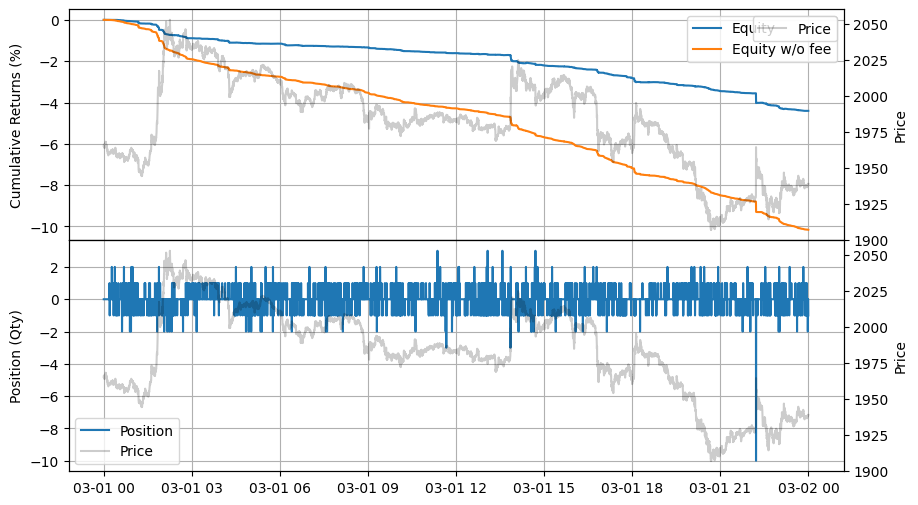

In [20]:
stats.plot()

## Adjustment factors
## 调整因素

It looks like the skew is too strong, which is why the market maker is hesitant to take on the position. To alleviate the skew, you can introduce adjustment factors, $adj_1$ and $adj_2$, to the calculated half spread and skew, as follow.

看起来这种偏差太严重了，这就是市场做市商不愿接手该头寸的原因。为了缓解这种偏差，您可以为计算出的半价差和偏差引入调整因子 $adj_1$ 和 $adj_2$，具体如下。

$$
\text{half spread}_{adj} = \text{half spread} \times adj_1 \\
\text{skew}_{adj} = \text{skew} \times adj_2
$$

In [21]:
from numba.typed import Dict

@njit
def glft_market_maker(hbt, recorder):
    tick_size = hbt.depth(0).tick_size
    arrival_depth = np.full(10_000_000, np.nan, np.float64)
    mid_price_chg = np.full(10_000_000, np.nan, np.float64)
    out = np.zeros(10_000_000, out_dtype)

    t = 0
    prev_mid_price_tick = np.nan
    mid_price_tick = np.nan
    
    tmp = np.zeros(500, np.float64)
    ticks = np.arange(len(tmp)) + 0.5
    
    A = np.nan
    k = np.nan
    volatility = np.nan
    gamma = 0.05
    delta = 1
    adj1 = 1
    adj2 = 0.05 # Uses the same value as gamma.

    order_qty = 1
    max_position = 20
    
    # Checks every 100 milliseconds.
    while hbt.elapse(100_000_000) == 0:
        #--------------------------------------------------------
        # Records market order's arrival depth from the mid-price.
        if not np.isnan(mid_price_tick):
            depth = -np.inf
            for last_trade in hbt.last_trades(0):
                trade_price_tick = last_trade.px / tick_size
                
                if last_trade.ev & BUY_EVENT == BUY_EVENT:
                    depth = np.nanmax([trade_price_tick - mid_price_tick, depth])
                else:
                    depth = np.nanmax([mid_price_tick - trade_price_tick, depth])
            arrival_depth[t] = depth
        
        hbt.clear_last_trades(0)
        hbt.clear_inactive_orders(0)
        
        depth = hbt.depth(0)
        position = hbt.position(0)
        orders = hbt.orders(0)

        best_bid_tick = depth.best_bid_tick
        best_ask_tick = depth.best_ask_tick
        
        prev_mid_price_tick = mid_price_tick
        mid_price_tick = (best_bid_tick + best_ask_tick) / 2.0
        
        # Records the mid-price change for volatility calculation.
        mid_price_chg[t] = mid_price_tick - prev_mid_price_tick
        
        #--------------------------------------------------------
        # Calibrates A, k and calculates the market volatility.
        
        # Updates A, k, and the volatility every 5-sec.
        if t % 50 == 0:
            # Window size is 10-minute.
            if t >= 6_000 - 1:
                # Calibrates A, k
                tmp[:] = 0
                lambda_ = measure_trading_intensity(arrival_depth[t + 1 - 6_000:t + 1], tmp)
                if len(lambda_) > 2:
                    lambda_ = lambda_[:70] / 600
                    x = ticks[:len(lambda_)]
                    y = np.log(lambda_)
                    k_, logA = linear_regression(x, y)
                    A = np.exp(logA)
                    k = -k_
           
                # Updates the volatility.
                volatility = np.nanstd(mid_price_chg[t + 1 - 6_000:t + 1]) * np.sqrt(10)
    
        #--------------------------------------------------------
        # Computes bid price and ask price.
    
        c1, c2 = compute_coeff(gamma, gamma, delta, A, k)
        
        half_spread_tick = (c1 + delta / 2 * c2 * volatility) * adj1
        skew = c2 * volatility * adj2
        
        reservation_price_tick = mid_price_tick - skew * position

        bid_price_tick = np.minimum(np.round(reservation_price_tick - half_spread_tick), best_bid_tick)
        ask_price_tick = np.maximum(np.round(reservation_price_tick + half_spread_tick), best_ask_tick)
        
        bid_price = bid_price_tick * tick_size
        ask_price = ask_price_tick * tick_size
        
        #--------------------------------------------------------
        # Updates quotes.
        
        # Cancel orders if they differ from the updated bid and ask prices.
        order_values = orders.values();
        while order_values.has_next():
            order = order_values.get()
            # Cancels if a working order is not in the new grid.
            if order.cancellable:
                if (
                    (order.side == BUY and order.price_tick != bid_price_tick)
                    or (order.side == SELL and order.price_tick != ask_price_tick)
                ):
                    hbt.cancel(0, order.order_id, False)

        # If the current position is within the maximum position,
        # submit the new order only if no order exists at the same price.
        if position < max_position and np.isfinite(bid_price):
            bid_price_as_order_id = round(bid_price / tick_size)
            if bid_price_as_order_id not in orders:
                hbt.submit_buy_order(0, bid_price_as_order_id, bid_price, order_qty, GTX, LIMIT, False)
        if position > -max_position and np.isfinite(ask_price):
            ask_price_as_order_id = round(ask_price / tick_size)
            if ask_price_as_order_id not in orders:
                hbt.submit_sell_order(0, ask_price_as_order_id, ask_price, order_qty, GTX, LIMIT, False)
                
        #--------------------------------------------------------
        # Records variables and stats for analysis.
        
        out[t].half_spread_tick = half_spread_tick
        out[t].skew = skew
        out[t].volatility = volatility
        out[t].A = A
        out[t].k = k
        
        t += 1
        
        if t >= len(arrival_depth) or t >= len(mid_price_chg) or t >= len(out):
            raise Exception
        
        # Records the current state for stat calculation.
        recorder.record(hbt)
    return out[:t]

In [22]:
asset = (
    BacktestAsset()
        .data([
            'usdm/ethusdc_20260301.npz'
        ])
        .initial_snapshot('usdm/ethusdc_20260228_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency([
            'usdm/feed_latency_ethusdc_20260301.npz'
        ])
        .power_prob_queue_model(2.0) 
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.01)
        .lot_size(0.001)
        .roi_lb(0.0)    
        .roi_ub(3000.0)
        .last_trades_capacity(10000)
)

hbt = ROIVectorMarketDepthBacktest([asset])

recorder = Recorder(1, 5_000_000)

out = glft_market_maker(hbt, recorder.recorder)

hbt.close()

stats = LinearAssetRecord(recorder.get(0)).stats(book_size=30_000)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-03-01 00:00:00,2026-03-01 23:59:50,-40.431997,-41.542343,-0.047747,0.049679,11783.363815,778.976397,-0.961106,-0.000061,39287.8


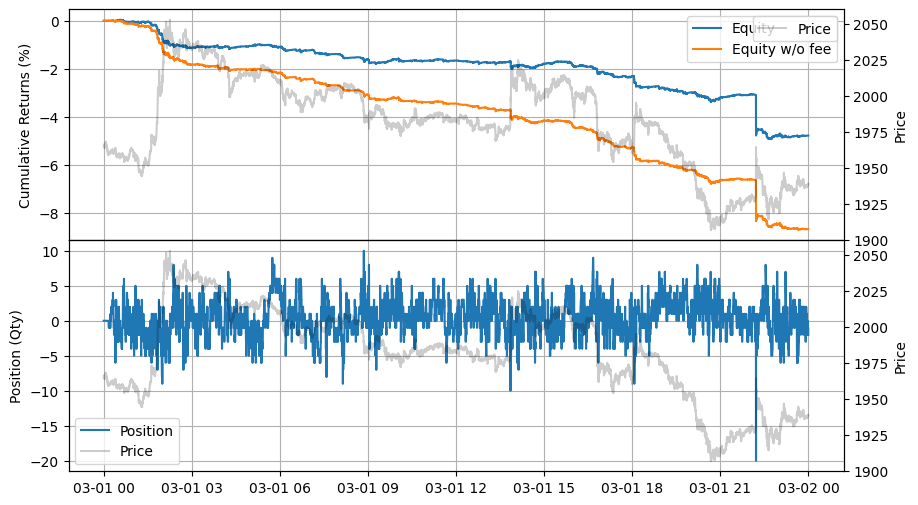

In [24]:
stats.plot()

Improved, but even when accounting for rebates, it can only achieve breakeven at best. As shown below, both the half spread and skew move together, primarily influenced by the $c_2$ and the market volatility.

有所改善，但即便考虑到返利因素，其收益也只能勉强达到收支平衡。如图所示，半价差和偏度是同步变动的，主要受 $c_2$ 和市场波动率的影响。

Text(0, 0.5, 'Skew (tick)')

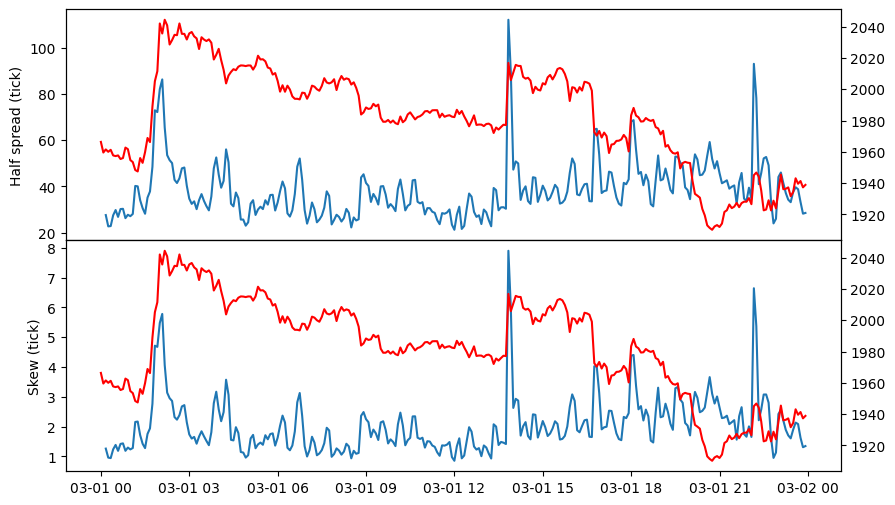

In [25]:
import polars as pl

records = recorder.get(0)
df = pl.DataFrame(out).with_columns(
    pl.Series('timestamp', records['timestamp']),
    pl.Series('price', records['price'])
).with_columns(
    pl.from_epoch('timestamp', time_unit='ns')
)

df = df.group_by_dynamic(
    'timestamp', every='5m'
).agg(
    pl.col('price').last(),
    pl.col('half_spread_tick').last(),
    pl.col('skew').last(),
    pl.col('volatility').last(),
    pl.col('A').last(),
    pl.col('k').last(),
)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0)
fig.set_size_inches(10, 6)

ax1.plot(df['timestamp'], df['half_spread_tick'])
ax1.twinx().plot(df['timestamp'], df['price'], 'r')
ax1.set_ylabel('Half spread (tick)')

ax2.plot(df['timestamp'], df['skew'])
ax2.twinx().plot(df['timestamp'], df['price'], 'r')
ax2.set_ylabel('Skew (tick)')

Text(0, 0.5, 'k ($ tick^{-1} $)')

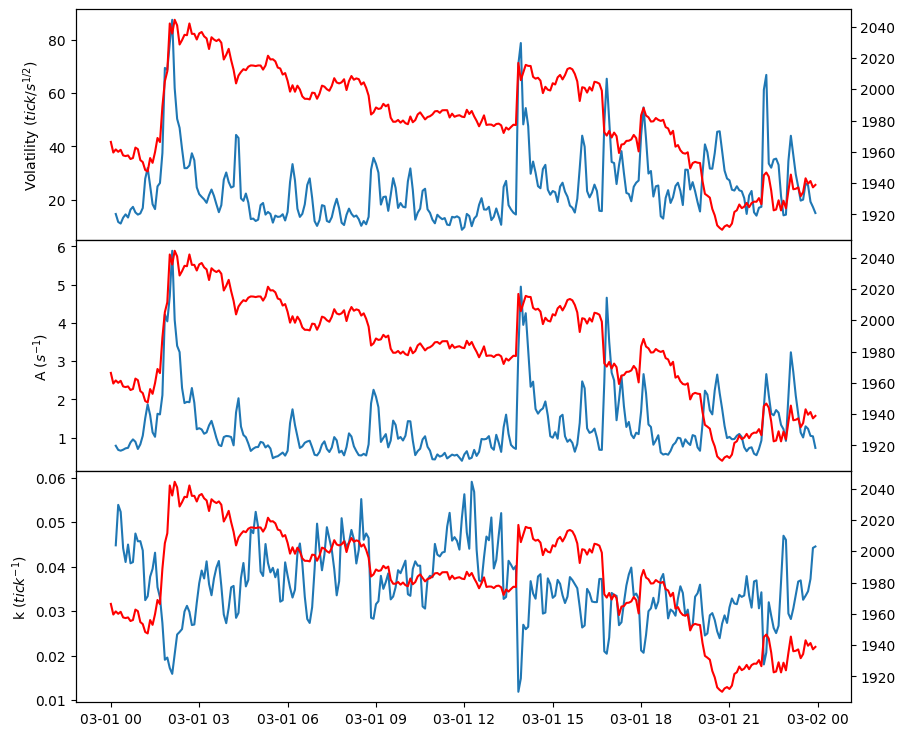

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
fig.subplots_adjust(hspace=0)
fig.set_size_inches(10, 9)

ax1.plot(df['timestamp'], df['volatility'])
ax1.twinx().plot(df['timestamp'], df['price'], 'r')
ax1.set_ylabel('Volatility ($ tick/s^{1/2} $)')

ax2.plot(df['timestamp'], df['A'])
ax2.twinx().plot(df['timestamp'], df['price'], 'r')
ax2.set_ylabel('A ($ s^{-1} $)')

ax3.plot(df['timestamp'], df['k'])
ax3.twinx().plot(df['timestamp'], df['price'], 'r')
ax3.set_ylabel('k ($ tick^{-1} $)')

In the 5-day backtest, it's evident that profits are generated through rebates, as a result of maintaining high trading volume by consistently posting quotes.

在为期 5 天的回测中，很明显利润是通过返利实现的，这是因为通过持续发布报价来保持了较高的交易量。

In [27]:
asset = (
    BacktestAsset()
        .data([
            'usdm/ethusdc_20260301.npz',
            'usdm/ethusdc_20260302.npz',
            'usdm/ethusdc_20260303.npz'
        ])
        .initial_snapshot('usdm/ethusdc_20260228_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency([
            'usdm/feed_latency_ethusdc_20260301.npz',
            'usdm/feed_latency_ethusdc_20260302.npz',
            'usdm/feed_latency_ethusdc_20260303.npz'
        ])
        .power_prob_queue_model(2.0) 
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.01)
        .lot_size(0.001)
        .roi_lb(0.0)    
        .roi_ub(3000.0)
        .last_trades_capacity(10000)
)

hbt = ROIVectorMarketDepthBacktest([asset])

recorder = Recorder(1, 5_000_000)

out = glft_market_maker(hbt, recorder.recorder)

hbt.close()

stats = LinearAssetRecord(recorder.get(0)).stats(book_size=30_000)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-03-01 00:00:00,2026-03-03 23:59:50,-28.417049,-30.15769,-0.067338,0.068385,15933.281377,1054.141983,-0.984699,-0.000021,39287.8


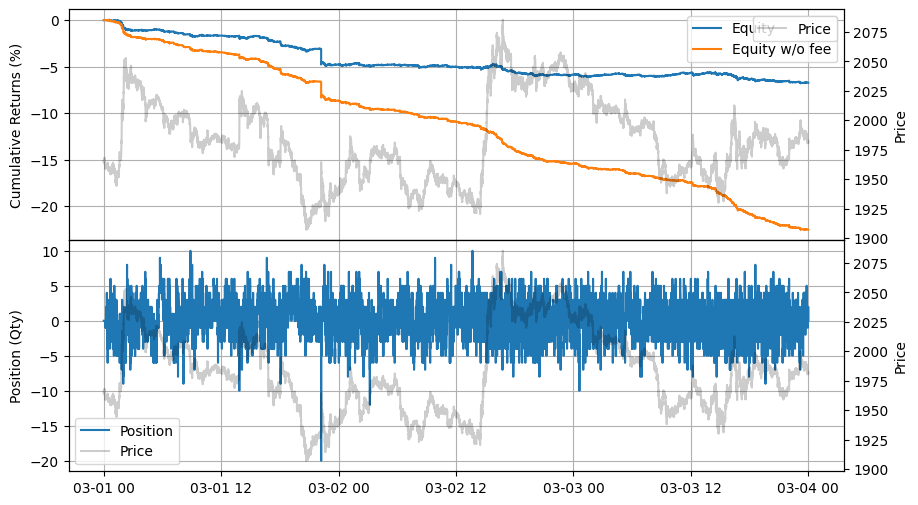

In [28]:
stats.plot()

## Integrating Grid Trading
## 整合网格交易

Creating a grid from the bid and ask prices derived from the Guéant–Lehalle–Fernandez-Tapia market making model.

根据盖昂-勒哈勒-费尔南德斯-塔皮亚的做市商模型所得出的买价和卖价，构建一个网格。

In [29]:
from numba.typed import Dict
from numba import uint64

@njit
def gridtrading_glft_mm(hbt, recorder):
    asset_no = 0
    tick_size = hbt.depth(asset_no).tick_size
    
    arrival_depth = np.full(10_000_000, np.nan, np.float64)
    mid_price_chg = np.full(10_000_000, np.nan, np.float64)

    t = 0
    prev_mid_price_tick = np.nan
    mid_price_tick = np.nan
    
    tmp = np.zeros(500, np.float64)
    ticks = np.arange(len(tmp)) + 0.5
    
    A = np.nan
    k = np.nan
    volatility = np.nan
    gamma = 0.05
    delta = 1
    adj1 = 1
    adj2 = 0.05

    order_qty = 1
    max_position = 20
    grid_num = 20
    
    # Checks every 100 milliseconds.
    while hbt.elapse(100_000_000) == 0:
        #--------------------------------------------------------
        # Records market order's arrival depth from the mid-price.
        if not np.isnan(mid_price_tick):
            depth = -np.inf
            for last_trade in hbt.last_trades(asset_no):
                trade_price_tick = last_trade.px / tick_size
                
                if last_trade.ev & BUY_EVENT == BUY_EVENT:
                    depth = np.nanmax([trade_price_tick - mid_price_tick, depth])
                else:
                    depth = np.nanmax([mid_price_tick - trade_price_tick, depth])
            arrival_depth[t] = depth
        
        hbt.clear_last_trades(asset_no)
        hbt.clear_inactive_orders(asset_no)
        
        depth = hbt.depth(asset_no)
        position = hbt.position(asset_no)
        orders = hbt.orders(asset_no)

        best_bid_tick = depth.best_bid_tick
        best_ask_tick = depth.best_ask_tick
        
        prev_mid_price_tick = mid_price_tick
        mid_price_tick = (best_bid_tick + best_ask_tick) / 2.0
        
        # Records the mid-price change for volatility calculation.
        mid_price_chg[t] = mid_price_tick - prev_mid_price_tick
        
        #--------------------------------------------------------
        # Calibrates A, k and calculates the market volatility.
        
        # Updates A, k, and the volatility every 5-sec.
        if t % 50 == 0:
            # Window size is 10-minute.
            if t >= 6_000 - 1:
                # Calibrates A, k
                tmp[:] = 0
                lambda_ = measure_trading_intensity(arrival_depth[t + 1 - 6_000:t + 1], tmp)
                if len(lambda_) > 2:
                    lambda_ = lambda_[:70] / 600
                    x = ticks[:len(lambda_)]
                    y = np.log(lambda_)
                    k_, logA = linear_regression(x, y)
                    A = np.exp(logA)
                    k = -k_
           
                # Updates the volatility.
                volatility = np.nanstd(mid_price_chg[t + 1 - 6_000:t + 1]) * np.sqrt(10)

        #--------------------------------------------------------
        # Computes bid price and ask price.
    
        c1, c2 = compute_coeff(gamma, gamma, delta, A, k)
        
        half_spread_tick = (c1 + delta / 2 * c2 * volatility) * adj1
        skew = c2 * volatility * adj2
        
        reservation_price_tick = mid_price_tick - skew * position

        bid_price_tick = np.minimum(np.round(reservation_price_tick - half_spread_tick), best_bid_tick)
        ask_price_tick = np.maximum(np.round(reservation_price_tick + half_spread_tick), best_ask_tick)
        
        bid_price = bid_price_tick * tick_size
        ask_price = ask_price_tick * tick_size

        grid_interval = max(np.round(half_spread_tick) * tick_size, tick_size)

        bid_price = np.floor(bid_price / grid_interval) * grid_interval
        ask_price = np.ceil(ask_price / grid_interval) * grid_interval
        
        #--------------------------------------------------------
        # Updates quotes.
        
        # Creates a new grid for buy orders.
        new_bid_orders = Dict.empty(np.uint64, np.float64)
        if position < max_position and np.isfinite(bid_price):
            for i in range(grid_num):
                bid_price_tick = round(bid_price / tick_size)
                
                # order price in tick is used as order id.
                new_bid_orders[uint64(bid_price_tick)] = bid_price
                
                bid_price -= grid_interval

        # Creates a new grid for sell orders.
        new_ask_orders = Dict.empty(np.uint64, np.float64)
        if position > -max_position and np.isfinite(ask_price):
            for i in range(grid_num):
                ask_price_tick = round(ask_price / tick_size)
                
                # order price in tick is used as order id.
                new_ask_orders[uint64(ask_price_tick)] = ask_price

                ask_price += grid_interval
                
        order_values = orders.values();
        while order_values.has_next():
            order = order_values.get()
            # Cancels if a working order is not in the new grid.
            if order.cancellable:
                if (
                    (order.side == BUY and order.order_id not in new_bid_orders)
                    or (order.side == SELL and order.order_id not in new_ask_orders)
                ):
                    hbt.cancel(asset_no, order.order_id, False)
                    
        for order_id, order_price in new_bid_orders.items():
            # Posts a new buy order if there is no working order at the price on the new grid.
            if order_id not in orders:
                hbt.submit_buy_order(asset_no, order_id, order_price, order_qty, GTX, LIMIT, False)
                
        for order_id, order_price in new_ask_orders.items():
            # Posts a new sell order if there is no working order at the price on the new grid.
            if order_id not in orders:
                hbt.submit_sell_order(asset_no, order_id, order_price, order_qty, GTX, LIMIT, False)
                
        #--------------------------------------------------------
        # Records variables and stats for analysis.
        
        t += 1
        
        if t >= len(arrival_depth) or t >= len(mid_price_chg):
            raise Exception
        
        # Records the current state for stat calculation.
        recorder.record(hbt)
    return out[:t]

In [30]:
asset = (
    BacktestAsset()
        .data([
            'usdm/ethusdc_20260301.npz',
            'usdm/ethusdc_20260302.npz',
            'usdm/ethusdc_20260303.npz'
        ])
        .initial_snapshot('usdm/ethusdc_20260228_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency([
            'usdm/feed_latency_ethusdc_20260301.npz',
            'usdm/feed_latency_ethusdc_20260302.npz',
            'usdm/feed_latency_ethusdc_20260303.npz'
        ])
        .power_prob_queue_model(2.0) 
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.01)
        .lot_size(0.001)
        .roi_lb(0.0)    
        .roi_ub(3000.0)
        .last_trades_capacity(10000)
)

hbt = ROIVectorMarketDepthBacktest([asset])

recorder = Recorder(1, 5_000_000)

out = gridtrading_glft_mm(hbt, recorder.recorder)

hbt.close()

stats = LinearAssetRecord(recorder.get(0)).stats(book_size=30_000)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-03-01 00:00:00,2026-03-03 23:59:50,-17.354844,-18.832061,-0.063675,0.069492,8686.335121,574.335563,-0.916302,-0.000037,41303.535


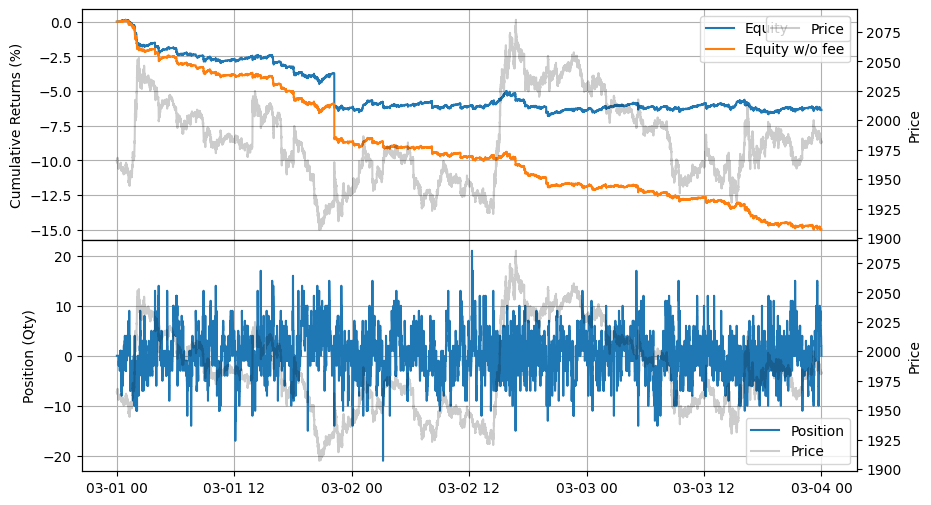

In [31]:
stats.plot()

You can see it works even better with other coins as well. In the next example, we will show how to create multiple markets to achieve better risk-adjusted returns.

您会发现，它与其他货币组合使用时效果也更佳。在接下来的示例中，我们将展示如何创建多个市场以实现更优的风险调整后收益。

In [ ]:
asset = (
    BacktestAsset()
        .data([
            'data/ltcusdt_20230701.npz',
            'data/ltcusdt_20230702.npz',
            'data/ltcusdt_20230703.npz',
            'data/ltcusdt_20230704.npz',
            'data/ltcusdt_20230705.npz'
        ])
        .initial_snapshot('data/ltcusdt_20230630_eod.npz')
        .linear_asset(1.0) 
        .intp_order_latency([
            'latency/feed_latency_20230701.npz',
            'latency/feed_latency_20230702.npz',
            'latency/feed_latency_20230703.npz',
            'latency/feed_latency_20230704.npz',
            'latency/feed_latency_20230705.npz'
        ])
        .power_prob_queue_model(2.0) 
        .no_partial_fill_exchange()
        .trading_value_fee_model(-0.00005, 0.0007)
        .tick_size(0.01)
        .lot_size(0.001)
        .roi_lb(0.0)    
        .roi_ub(300.0)
        .last_trades_capacity(10000)
)

hbt = ROIVectorMarketDepthBacktest([asset])

recorder = Recorder(1, 5_000_000)

out = gridtrading_glft_mm(hbt, recorder.recorder)

hbt.close()

stats = LinearAssetRecord(recorder.get(0)).stats(book_size=3000)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-07-01 00:00:00,2023-07-05 23:59:50,17.17992,23.062973,0.122535,0.032973,3425.879303,122.800909,3.716196,0.0002,2930.06


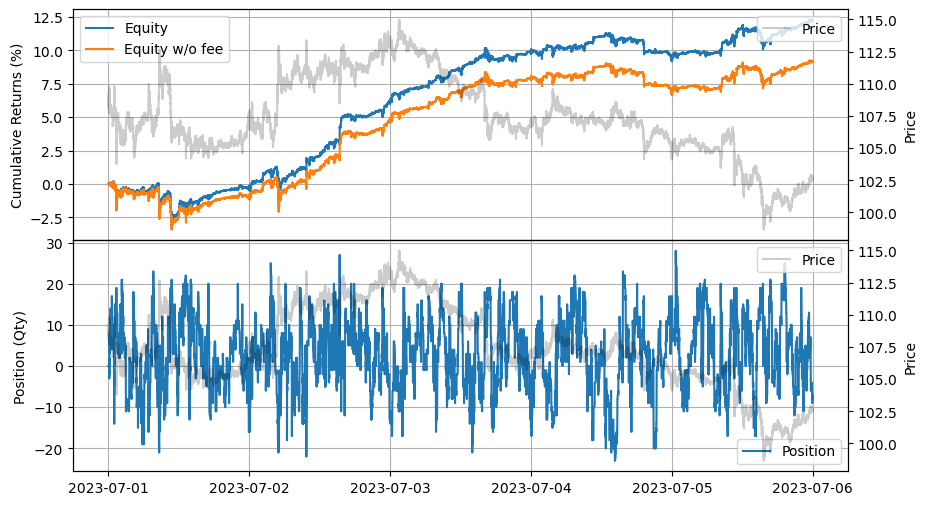

In [ ]:
stats.plot()

## Wrapping up
## 总结

Thus far, we have illustrated how to apply the model to a real-world example.

至此，我们已经展示了如何将该模型应用于实际案例中。

For a more effective market-making algorithm, consider dividing this model into the following categories:

为了实现更高效的做市算法，可以将此模型划分为以下几类：

* Half-spread: As shown, the half-spread is a function of trading intensity and market volatility. An exponential function used for trading intensity might not be suitable for the entire range. You could develop a more refined approach to convert trading intensity to half-spread. Additionally, while historical trading intensity and market volatility are utilized here, you could forecast short-term trading intensity and volatility to respond more agilely to changes in market conditions. This might involve strategies that use news, events, liquidity vacuums, and other factors to predict volatility explosions.
  
* 半波幅：如图所示，半波幅与交易强度和市场波动性有关。用于衡量交易强度的指数函数可能并不适用于整个范围。您可以开发一种更精细的方法将交易强度转换为半波幅。此外，虽然这里使用了历史交易强度和市场波动性数据，但您还可以预测短期交易强度和波动性，以便更灵活地应对市场状况的变化。这可能涉及利用新闻、事件、流动性真空以及其他因素来预测波动性爆发的策略。


* Skew: The skew is also a function of trading intensity and market volatility. In this model, only inventory risk is considered, but you can also account for other risks, particularly when making multiple markets. BARRA is a good example of other risks that can be managed similarly.
  
* 偏斜度：偏斜度还受交易强度和市场波动性的影响。在该模型中，仅考虑了库存风险，但您也可以考虑其他风险，尤其是在进行多市场操作时。巴拉就是一个很好的例子，说明了其他风险也可以以类似的方式进行管理。


* Fair Value Pricing: In this model, the fair price is equal to the mid-price, however, you need to incorporate forecasts such as the micro-price and fair value pricing through correlated assets to enhance the strategy.

* 公允价值定价：在该模型中，公允价格等于中间价。然而，您需要结合诸如微观价格和公允价值定价等预测信息，通过相关资产来完善这一策略。


* Hedging: Hedging is especially crucial when making multiple markets, as it serves as a valuable tool for managing risks.
  
* 套期保值：在进行多市场交易时，套期保值尤为重要，因为它是一种有效的风险管理工具。
  
We will address a few more topics in upcoming examples.

在接下来的示例中，我们将再探讨几个相关主题。

## References
## 参考文献
[Dealing with the Inventory Risk - A solution to the market making problem](https://arxiv.org/abs/1105.3115)  
[Optimal market making](https://arxiv.org/abs/1605.01862)  

Knight Capital Group  
[Stochastic Control Theory and High Frequency Trading](https://ieor.columbia.edu/files/seasdepts/industrial-engineering-operations-research/pdf-files/Borden_D_FESeminar_Sp10.pdf)  

BitMEX Market Making Series  
[Algo Trading & Market Making](https://blog.bitmex.com/wp-content/uploads/2019/11/Algo-Trading-and-Market-Making.pdf)  
[How to Market Make Bitcoin Derivatives Lesson 1](https://blog.bitmex.com/how-to-market-make-bitcoin-derivatives-lesson-1/)  
[How to Market Make Bitcoin Derivatives Lesson 2](https://blog.bitmex.com/how-to-market-make-bitcoin-derivatives-lesson-2/)  